# Individual Assignment - 1

Acknowledgement of AI used:
I used an AI tool (Claude) to assist with translating the R workflow into Python and to help clarify concepts. All codes and interpretation were reviewed, understood, and finalized by me.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import statsmodels.api as sm
from sklearn.metrics import confusion_matrix

## 2. Loading the Data


In [ ]:
# Load raw data from ProPublica GitHub
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
raw_data = pd.read_csv(url)

print(f"Number of rows: {len(raw_data)}")

Number of rows: 7214


In [ ]:
raw_data.head(10)

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0
5,7,marsha miles,marsha,miles,2013-11-30,Male,1971-08-22,44,25 - 45,Other,...,1,Low,2013-11-30,2013-11-30,2013-12-01,0,1,853,0,0
6,8,edward riddle,edward,riddle,2014-02-19,Male,1974-07-23,41,25 - 45,Caucasian,...,2,Low,2014-02-19,2014-03-31,2014-04-18,14,5,40,1,1
7,9,steven stewart,steven,stewart,2013-08-30,Male,1973-02-25,43,25 - 45,Other,...,3,Low,2013-08-30,2014-05-22,2014-06-03,3,0,265,0,0
8,10,elizabeth thieme,elizabeth,thieme,2014-03-16,Female,1976-06-03,39,25 - 45,Caucasian,...,1,Low,2014-03-16,2014-03-15,2014-03-18,0,2,747,0,0
9,13,bo bradac,bo,bradac,2013-11-04,Male,1994-06-10,21,Less than 25,Caucasian,...,5,Medium,2013-11-04,2015-01-06,2015-01-07,1,0,428,1,1


## 3. Data Cleaning and Preprocessing

In [ ]:
# Select relevant columns
cols = [
    'age', 'c_charge_degree', 'race', 'age_cat', 'score_text', 'sex',
    'priors_count', 'days_b_screening_arrest', 'decile_score',
    'is_recid', 'two_year_recid', 'c_jail_in', 'c_jail_out'
]
df = raw_data[cols].copy()

# Filtering
df = df[df['days_b_screening_arrest'].between(-30, 30)]
df = df[df['is_recid'] != -1]
df = df[df['c_charge_degree'] != 'O']
df = df[df['score_text'] != 'N/A']
df = df.reset_index(drop=True)

print(f"Rows after filtering: {len(df)}")

# Parse datetime columns
df['c_jail_in']  = pd.to_datetime(df['c_jail_in'],  errors='coerce')
df['c_jail_out'] = pd.to_datetime(df['c_jail_out'], errors='coerce')

# Derived variables
# crime_factor: felony (F) vs misdemeanor (M)
df['crime_factor'] = df['c_charge_degree'].astype('category')

# age_factor: reference level = '25 - 45'
age_order = ['25 - 45', 'Greater than 45', 'Less than 25']
df['age_factor'] = pd.Categorical(df['age_cat'], categories=age_order, ordered=False)

# race_factor: reference level = 'Caucasian'
races = ['Caucasian', 'African-American', 'Asian', 'Hispanic', 'Native American', 'Other']
df['race_factor'] = pd.Categorical(df['race'], categories=races, ordered=False)

# gender_factor: reference level = 'Male'
df['gender_factor'] = pd.Categorical(df['sex'], categories=['Male', 'Female'], ordered=False)

# score_factor: 'LowScore' if score_text == 'Low', else 'HighScore'
df['score_factor'] = np.where(df['score_text'] == 'Low', 'LowScore', 'HighScore')
df['score_factor'] = pd.Categorical(df['score_factor'],
                                     categories=['LowScore', 'HighScore'], ordered=False)

Rows after filtering: 6172


In [ ]:
df.head()

,age,c_charge_degree,race,age_cat,score_text,sex,priors_count,days_b_screening_arrest,decile_score,is_recid,two_year_recid,c_jail_in,c_jail_out,crime_factor,age_factor,race_factor,gender_factor,score_factor
0,69,F,Other,Greater than 45,Low,Male,0,-1.0,1,0,0,2013-08-13 06:03:42,2013-08-14 05:41:20,F,Greater than 45,Other,Male,LowScore
1,34,F,African-American,25 - 45,Low,Male,0,-1.0,3,1,1,2013-01-26 03:45:27,2013-02-05 05:36:53,F,25 - 45,African-American,Male,LowScore
2,24,F,African-American,Less than 25,Low,Male,4,-1.0,4,1,1,2013-04-13 04:58:34,2013-04-14 07:02:04,F,Less than 25,African-American,Male,LowScore
3,44,M,Other,25 - 45,Low,Male,0,0.0,1,0,0,2013-11-30 04:50:18,2013-12-01 12:28:56,M,25 - 45,Other,Male,LowScore
4,41,F,Caucasian,25 - 45,Medium,Male,14,-1.0,6,1,1,2014-02-18 05:08:24,2014-02-24 12:18:30,F,25 - 45,Caucasian,Male,HighScore


In [ ]:
print(df.dtypes)
print(f"\nShape: {df.shape}")

age                                 int64
c_charge_degree                    object
race                               object
age_cat                            object
score_text                         object
sex                                object
priors_count                        int64
days_b_screening_arrest           float64
decile_score                        int64
is_recid                            int64
two_year_recid                      int64
c_jail_in                  datetime64[ns]
c_jail_out                 datetime64[ns]
crime_factor                     category
age_factor                       category
race_factor                      category
gender_factor                    category
score_factor                     category
dtype: object

Shape: (6172, 18)



## 4. Exploratory Data Analysis (EDA)

In [ ]:
# Length of stay (jail days) and correlation with COMPAS decile score
df['length_of_stay'] = (df['c_jail_out'] - df['c_jail_in']).dt.days
corr_val = df[['length_of_stay', 'decile_score']].dropna().corr().iloc[0, 1]
print(f"Correlation (length_of_stay, decile_score): {corr_val:.7f}")

Correlation (length_of_stay, decile_score): 0.2074781


In [ ]:
# Age category breakdown
print("Age category counts:")
print(df['age_cat'].value_counts().sort_index())

Age category counts:
age_cat
25 - 45            3532
Greater than 45    1293
Less than 25       1347
Name: count, dtype: int64


In [ ]:
# Race breakdown
print("Race counts:")
print(df['race'].value_counts())

Race counts:
race
African-American    3175
Caucasian           2103
Hispanic             509
Other                343
Asian                 31
Native American       11
Name: count, dtype: int64


In [ ]:
# Race percentages
n = len(df)
race_counts = df['race'].value_counts()
print(f"Black defendants:          {race_counts.get('African-American', 0) / n * 100:.2f}%")
print(f"White defendants:          {race_counts.get('Caucasian', 0) / n * 100:.2f}%")
print(f"Hispanic defendants:       {race_counts.get('Hispanic', 0) / n * 100:.2f}%")
print(f"Asian defendants:          {race_counts.get('Asian', 0) / n * 100:.2f}%")
print(f"Native American defendants:{race_counts.get('Native American', 0) / n * 100:.2f}%")

Black defendants:          51.44%
White defendants:          34.07%
Hispanic defendants:       8.25%
Asian defendants:          0.50%
Native American defendants:0.18%


In [ ]:
# Score text breakdown
print("Score text counts:")
print(df['score_text'].value_counts())

Score text counts:
score_text
Low       3421
Medium    1607
High      1144
Name: count, dtype: int64


In [ ]:
# Sex × Race cross-tabulation
print("Sex × Race cross-tabulation:")
print(pd.crosstab(df['sex'], df['race']))

Sex × Race cross-tabulation:
race    African-American  Asian  Caucasian  Hispanic  Native American  Other
sex                                                                         
Female               549      2        482        82                2     58
Male                2626     29       1621       427                9    285


In [ ]:
# Sex breakdown
sex_counts = df['sex'].value_counts()
print("Sex counts:")
print(sex_counts)
print(f"\nMen:   {sex_counts.get('Male', 0) / n * 100:.2f}%")
print(f"Women: {sex_counts.get('Female', 0) / n * 100:.2f}%")

Sex counts:
sex
Male      4997
Female    1175
Name: count, dtype: int64

Men:   80.96%
Women: 19.04%


In [ ]:
# Two-year recidivism rate
recid_count = (df['two_year_recid'] == 1).sum()
print(f"Two-year recidivists: {recid_count}")
print(f"Recidivism rate:      {recid_count / n * 100:.5f}%")

Two-year recidivists: 2809
Recidivism rate:      45.51199%


### 4.1 Visualisation: Decile Score by Race

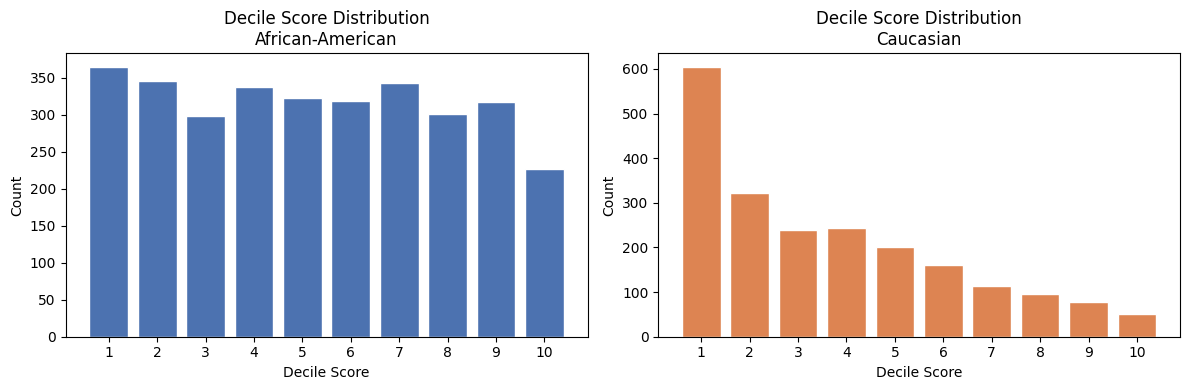

Figure saved as decile_score_by_race.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

for ax, (race_label, color) in zip(axes,
        [('African-American', '#4C72B0'), ('Caucasian', '#DD8452')]):
    subset = df[df['race'] == race_label]['decile_score'].value_counts().sort_index()
    ax.bar(subset.index, subset.values, color=color, edgecolor='white')
    ax.set_title(f'Decile Score Distribution\n{race_label}', fontsize=12)
    ax.set_xlabel('Decile Score')
    ax.set_ylabel('Count')
    ax.set_xticks(range(1, 11))

plt.tight_layout()
plt.savefig('decile_score_by_race.png', dpi=120, bbox_inches='tight')
plt.show()
print("Figure saved as decile_score_by_race.png")

## 5. Logistic Regression Model

In [ ]:
# Encode binary response: HighScore = 1, LowScore = 0
df['score_binary'] = (df['score_factor'] == 'HighScore').astype(int)

# statsmodels formula — C(var, Treatment('ref')) sets reference level
formula = (
    "score_binary ~ "
    "C(gender_factor, Treatment('Male')) + "
    "C(age_factor, Treatment('25 - 45')) + "
    "C(race_factor, Treatment('Caucasian')) + "
    "priors_count + "
    "C(crime_factor, Treatment('M')) + "
    "two_year_recid"
)

model_glm = smf.logit(formula, data=df).fit(disp=False)
print(model_glm.summary())

                           Logit Regression Results                           
Dep. Variable:           score_binary   No. Observations:                 6172
Model:                          Logit   Df Residuals:                     6160
Method:                           MLE   Df Model:                           11
Date:                Sun, 05 Apr 2026   Pseudo R-squ.:                  0.2729
Time:                        23:36:22   Log-Likelihood:                -3084.2
converged:                       True   LL-Null:                       -4241.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------------
Intercept                                                     -1.8368      0.084    -21.986      0.000      -2.001

### 5.1 Odds Ratio Interpretation


In [ ]:
# Extract coefficients
params = model_glm.params
print("Model coefficients:")
print(params)

# Intercept for control-group baseline probability
intercept = params['Intercept']
control = np.exp(intercept) / (1 + np.exp(intercept))
print(f"\nBaseline probability (control): {control:.5f}")

Model coefficients:
Intercept                                                    -1.836779
C(gender_factor, Treatment('Male'))[T.Female]                 0.221267
C(age_factor, Treatment('25 - 45'))[T.Greater than 45]       -1.355633
C(age_factor, Treatment('25 - 45'))[T.Less than 25]           1.308390
C(race_factor, Treatment('Caucasian'))[T.African-American]    0.477207
C(race_factor, Treatment('Caucasian'))[T.Asian]              -0.254415
C(race_factor, Treatment('Caucasian'))[T.Hispanic]           -0.428395
C(race_factor, Treatment('Caucasian'))[T.Native American]     1.394208
C(race_factor, Treatment('Caucasian'))[T.Other]              -0.826347
C(crime_factor, Treatment('M'))[T.F]                          0.311241
priors_count                                                  0.268945
two_year_recid                                                0.685863
dtype: float64

Baseline probability (control): 0.13743


In [ ]:
# Helper: compute relative risk from a log-odds coefficient
def relative_risk(coef, control):
    return np.exp(coef) / (1 - control + control * np.exp(coef))

# Gender effect: Female vs Male
female_coef_key = [k for k in params.index if 'Female' in k]
if female_coef_key:
    rr_female = relative_risk(params[female_coef_key[0]], control)
    print(f"Relative risk (Female vs Male): {rr_female:.4f}")
    print("Women are {:.1f}% more likely than men to get a higher score.".format(
          (rr_female - 1) * 100))

# Age effect: Less than 25 vs 25-45
young_coef_key = [k for k in params.index if 'Less than 25' in k]
if young_coef_key:
    rr_young = relative_risk(params[young_coef_key[0]], control)
    print(f"\nRelative risk (Under 25 vs 25-45): {rr_young:.5f}")
    print("People under 25 are {:.1f}x as likely to get a higher score.".format(rr_young))

Relative risk (Female vs Male): 1.2066
Women are 20.7% more likely than men to get a higher score.

Relative risk (Under 25 vs 25-45): 2.69872
People under 25 are 2.7x as likely to get a higher score.



## 6. Model Evaluation and Diagnostics


In [ ]:
# Generate predicted probabilities and binary classifications
df['pred_prob']  = model_glm.predict(df)
df['pred_class'] = np.where(df['pred_prob'] >= 0.5, 'Recid', 'No Recid')

In [ ]:
# Overall Confusion Matrix
print(" Overall Confusion Matrix")

actual    = df['two_year_recid'].astype(int)
predicted = (df['pred_class'] == 'Recid').astype(int)

# confusion_matrix
cm = confusion_matrix(actual, predicted)  # shape: [[TN, FP], [FN, TP]]
TN, FP, FN, TP = cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]
n_total = len(df)

overall_cm_df = pd.DataFrame(
    {'Actual 0': [TN, FP], 'Actual 1': [FN, TP]},
    index=['Predicted No Recid', 'Predicted Recid']
)
print(overall_cm_df)

print(f"\nAccuracy  : {(TP + TN) / n_total:.3f}")
print(f"Precision : {TP / (TP + FP):.3f}")
print(f"Recall    : {TP / (TP + FN):.3f}")
print(f"FPR       : {FP / (FP + TN):.3f}")
print(f"FNR       : {FN / (FN + TP):.3f}")

 Overall Confusion Matrix
                    Actual 0  Actual 1
Predicted No Recid      2653       945
Predicted Recid          710      1864

Accuracy  : 0.732
Precision : 0.724
Recall    : 0.664
FPR       : 0.211
FNR       : 0.336


In [ ]:
# Confusion Matrix by Race
print("Confusion Matrix by Race")

df['actual'] = df['two_year_recid'].astype(int)
df['pred']   = (df['pred_class'] == 'Recid').astype(int)

def race_metrics(group):
    TP = ((group['pred'] == 1) & (group['actual'] == 1)).sum()
    TN = ((group['pred'] == 0) & (group['actual'] == 0)).sum()
    FP = ((group['pred'] == 1) & (group['actual'] == 0)).sum()
    FN = ((group['pred'] == 0) & (group['actual'] == 1)).sum()
    n  = len(group)
    return pd.Series({
        'n':         n,
        'TP':        TP,
        'TN':        TN,
        'FP':        FP,
        'FN':        FN,
        'Accuracy':  round((TP + TN) / n, 3),
        'Precision': round(TP / (TP + FP), 3) if (TP + FP) > 0 else float('nan'),
        'Recall':    round(TP / (TP + FN), 3) if (TP + FN) > 0 else float('nan'),
        'FPR':       round(FP / (FP + TN), 3) if (FP + TN) > 0 else float('nan'),
        'FNR':       round(FN / (FN + TP), 3) if (FN + TP) > 0 else float('nan'),
    })

race_metrics_df = (
    df.groupby('race', observed=True)
      .apply(race_metrics)
      .reset_index()
      .sort_values('n', ascending=False)
)

print(race_metrics_df.to_string(index=False))

Confusion Matrix by Race
            race      n     TP     TN    FP    FN  Accuracy  Precision  Recall   FPR   FNR
African-American 3175.0 1373.0  959.0 555.0 288.0     0.734      0.712   0.827 0.367 0.173
       Caucasian 2103.0  381.0 1148.0 133.0 441.0     0.727      0.741   0.464 0.104 0.536
        Hispanic  509.0   81.0  306.0  14.0 108.0     0.760      0.853   0.429 0.044 0.571
           Other  343.0   22.0  216.0   3.0 102.0     0.694      0.880   0.177 0.014 0.823
           Asian   31.0    2.0   22.0   1.0   6.0     0.774      0.667   0.250 0.043 0.750
 Native American   11.0    5.0    2.0   4.0   0.0     0.636      0.556   1.000 0.667 0.000


/tmp/ipykernel_18030/2212473868.py:28: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(race_metrics)


In [ ]:
# FPR and FNR Disparity by Race
print("FPR and FNR Disparity by Race")

# Reference group: Caucasian
caucasian_row = race_metrics_df[race_metrics_df['race'] == 'Caucasian'].iloc[0]
ref_fpr = caucasian_row['FPR']
ref_fnr = caucasian_row['FNR']

disparity = race_metrics_df[['race', 'n', 'FPR', 'FNR']].copy()
disparity['delta_FPR'] = (disparity['FPR'] - ref_fpr).round(3)
disparity['delta_FNR'] = (disparity['FNR'] - ref_fnr).round(3)

print(disparity.to_string(index=False))
print("\nKey finding: FPR (Black) > FPR (White)")

FPR and FNR Disparity by Race
            race      n   FPR   FNR  delta_FPR  delta_FNR
African-American 3175.0 0.367 0.173      0.263     -0.363
       Caucasian 2103.0 0.104 0.536      0.000      0.000
        Hispanic  509.0 0.044 0.571     -0.060      0.035
           Other  343.0 0.014 0.823     -0.090      0.287
           Asian   31.0 0.043 0.750     -0.061      0.214
 Native American   11.0 0.667 0.000      0.563     -0.536

Key finding: FPR (Black) > FPR (White)


### 6.1 Visualisation: FPR and FNR Disparity


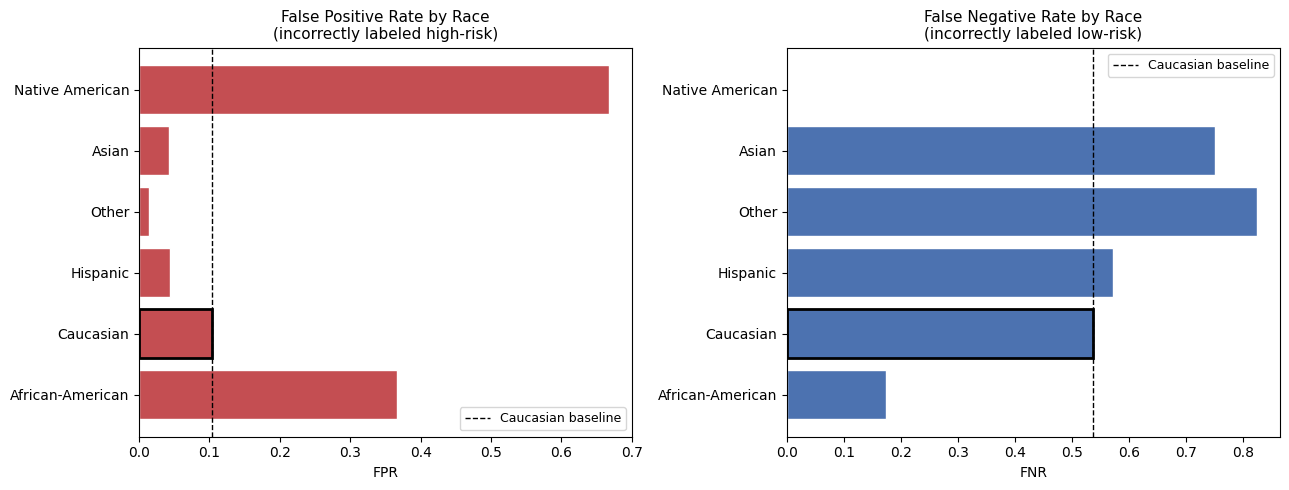

Figure saved as fpr_fnr_disparity.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

top_races = race_metrics_df.head(6)  # all 6 groups

for ax, metric, color, title in zip(
    axes,
    ['FPR', 'FNR'],
    ['#C44E52', '#4C72B0'],
    ['False Positive Rate by Race\n(incorrectly labeled high-risk)',
     'False Negative Rate by Race\n(incorrectly labeled low-risk)']
):
    bars = ax.barh(top_races['race'], top_races[metric], color=color, edgecolor='white')
    # Highlight Caucasian as reference
    for bar, race in zip(bars, top_races['race']):
        if race == 'Caucasian':
            bar.set_edgecolor('black')
            bar.set_linewidth(2)
    ax.set_xlabel(metric)
    ax.set_title(title, fontsize=11)
    ax.axvline(ref_fpr if metric == 'FPR' else ref_fnr,
               color='black', linestyle='--', linewidth=1, label='Caucasian baseline')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('fpr_fnr_disparity.png', dpi=120, bbox_inches='tight')
plt.show()
print("Figure saved as fpr_fnr_disparity.png")

## 7. Alignment Interpretation

The findings are:

- FPR(Black) > FPR(White): Black defendants are more likely to be
  incorrectly labeled high risk when they do not recidivate.
- FNR(White) > FNR(Black): White defendants are more likely to be
  incorrectly labeled low risk when they do recidivate.
- Calibration is approximately equal across groups (the model's
  predicted probabilities track actual recidivism similarly by race).




## 8. Individual Homework 2 — SHAP, LIME, DiCE

Builds on the GBT pipeline trained in Section 5.
Covers:
1. SHAP beeswarm + waterfall plots
2. LIME explanations + SHAP vs LIME comparison
3. DiCE counterfactuals
4. Governance memo


In [ ]:
# Install required libraries (run once)
!pip install shap lime dice-ml

import warnings
warnings.filterwarnings('ignore')

import shap
from lime.lime_tabular import LimeTabularExplainer
import dice_ml
from dice_ml import Dice
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 2.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 27.6 MB/s eta 0:00:00
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=0f6fac4c3f6c81311137461cc30ddb5e045ada12b726c82bdafd30c32c100f8d
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


### 8.1 Feature Definition and Train/Test Split


In [ ]:
target = 'two_year_recid'

numeric_features = [
    'age',
    'priors_count',
    'days_b_screening_arrest',
    'decile_score',
]

category_features = [
    'age_cat',
    'sex',
    'race',
    'c_charge_degree',
    'score_text',
]

X = df[numeric_features + category_features].copy()
y = df[target].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape}   Test: {X_test.shape}')

Train: (4937, 9)   Test: (1235, 9)


### 8.2 Preprocessor and Gradient-Boosted Tree (Black-Box Model)


In [ ]:
preprocessor = ColumnTransformer(
    [
        ('num', StandardScaler(), numeric_features),
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore', sparse_output=False),
            category_features,
        ),
    ]
)

gbt_pipeline = Pipeline(
    [
        ('preprocessor', preprocessor),
        (
            'classifier',
            GradientBoostingClassifier(
                n_estimators=200, max_depth=4, random_state=42
            ),
        ),
    ]
)
gbt_pipeline.fit(X_train, y_train)
print('GBT model trained.')

GBT model trained.


### 8.3 Group Performance Metrics by Race


In [ ]:
def group_metrics(pipeline, X, y, group_col='race'):
    results = []
    X_ = X.copy()
    X_['actual'] = y.values
    X_['pred'] = pipeline.predict(X)
    X_['pred_prob'] = pipeline.predict_proba(X)[:, 1]
    for group, gdf in X_.groupby(group_col):
        # Ensure confusion_matrix always returns 2x2 matrix for consistent unpacking
        tn, fp, fn, tp = confusion_matrix(
            gdf['actual'], gdf['pred'], labels=[0, 1]
        ).ravel()
        results.append(
            {
                'race': group,
                'n': len(gdf),
                'accuracy': round(accuracy_score(gdf['actual'], gdf['pred']), 3),
                'FPR': round(fp / (fp + tn + 1e-9), 3),
                'FNR': round(fn / (fn + tp + 1e-9), 3),
                'AUC': round(
                    roc_auc_score(gdf['actual'], gdf['pred_prob']), 3
                ),
            }
        )
    return pd.DataFrame(results).set_index('race')

print('\n── GBT performance by race ──')
print(group_metrics(gbt_pipeline, X_test, y_test))


── GBT performance by race ──
                    n  accuracy    FPR    FNR    AUC
race                                                
African-American  641     0.690  0.322  0.300  0.744
Asian               7     0.857  0.000  1.000  0.833
Caucasian         427     0.710  0.143  0.534  0.714
Hispanic           94     0.660  0.122  0.578  0.648
Native American     1     1.000  0.000  0.000    NaN
Other              65     0.723  0.106  0.722  0.746


### 8.4 Select Four Individuals (Highest / Lowest Risk per Racial Group)


In [ ]:
X_test_copy = X_test.copy()
X_test_copy['pred_prob'] = gbt_pipeline.predict_proba(X_test)[:, 1]
X_test_copy['actual'] = y_test.values

def pick_individuals(race_label):
    sub = X_test_copy[X_test_copy['race'] == race_label]
    high_idx = sub['pred_prob'].idxmax()
    low_idx  = sub['pred_prob'].idxmin()
    return high_idx, low_idx

black_high, black_low = pick_individuals('African-American')
white_high, white_low = pick_individuals('Caucasian')

individuals = {
    'Black – highest risk': black_high,
    'Black – lowest risk':  black_low,
    'White – highest risk': white_high,
    'White – lowest risk':  white_low,
}

print('Selected individuals:')
for label, idx in individuals.items():
    p = X_test_copy.loc[idx, 'pred_prob']
    print(f'  {label:30s}  pred_prob={p:.3f}  index={idx}')

Selected individuals:
  Black – highest risk            pred_prob=0.997  index=5388
  Black – lowest risk             pred_prob=0.027  index=3454
  White – highest risk            pred_prob=0.994  index=3772
  White – lowest risk             pred_prob=0.019  index=2636


### 8.5 SHAP Values


In [ ]:
# Computing SHAP values

X_test_enc  = preprocessor.transform(X_test)
X_train_enc = preprocessor.transform(X_train)

ohe_feature_names = (
    preprocessor.named_transformers_['cat']
    .get_feature_names_out(category_features)
    .tolist()
)
all_feature_names = numeric_features + ohe_feature_names

shap_explainer = shap.Explainer(
    gbt_pipeline['classifier']
    # The 'check_additivity' parameter is no longer supported in shap version 0.51.0
)
shap_values = shap_explainer(X_test_enc)

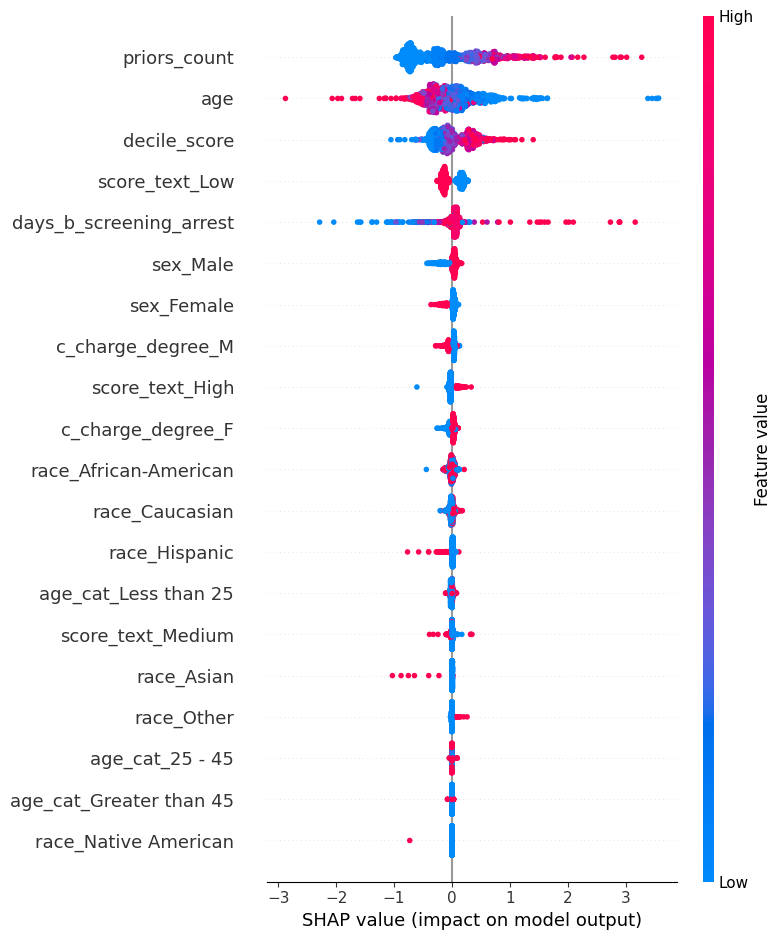

In [ ]:
# Global beeswarm plot
shap.summary_plot(
    shap_values,
    X_test_enc,
    feature_names=all_feature_names,
    show=True,
)

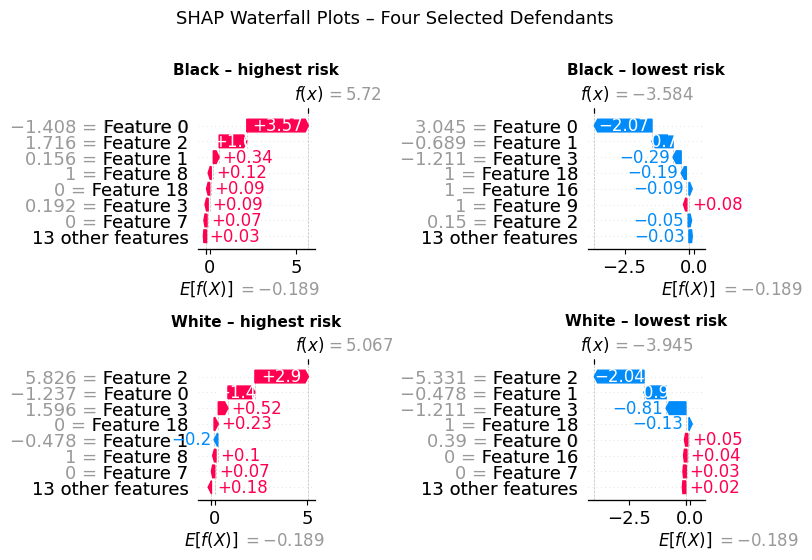

Saved: shap_waterfall.png


In [ ]:
# Waterfall plots for all 4 individuals
fig_wf, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, (label, idx) in zip(axes.flatten(), individuals.items()):
    loc = X_test.index.get_loc(idx)
    plt.sca(ax)
    shap.waterfall_plot(shap_values[loc], max_display=8, show=False)
    ax.set_title(label, fontsize=11, fontweight='bold')

plt.suptitle('SHAP Waterfall Plots – Four Selected Defendants', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('shap_waterfall.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: shap_waterfall.png')

### 8.6 LIME Explanations


In [ ]:
print('Running LIME …')

lime_explainer = LimeTabularExplainer(
    training_data=X_train_enc,
    feature_names=all_feature_names,
    class_names=['No Recid', 'Recid'],
    mode='classification',
    discretize_continuous=True,
    random_state=42,
)

lime_results = {}
for label, idx in individuals.items():
    loc = X_test.index.get_loc(idx)
    row = X_test_enc[loc]
    exp = lime_explainer.explain_instance(
        data_row=row,
        predict_fn=gbt_pipeline['classifier'].predict_proba,
        num_features=8,
    )
    lime_results[label] = exp.as_list()
    print(f'\n  LIME – {label}')
    print(f'  Predicted prob: {X_test_copy.loc[idx, "pred_prob"]:.3f}')
    for feat, wt in exp.as_list():
        print(f'    {feat:<45} {wt:+.4f}')

Running LIME …

  LIME – Black – highest risk
  Predicted prob: 0.997
    days_b_screening_arrest > 0.15                +0.3370
    race_Native American <= 0.00                  +0.2102
    age <= -0.81                                  +0.1342
    race_Asian <= 0.00                            +0.1337
    score_text_Low <= 0.00                        +0.0467
    -0.48 < priors_count <= 0.16                  -0.0444
    sex_Female <= 0.00                            +0.0246
    race_Hispanic <= 0.00                         +0.0243

  LIME – Black – lowest risk
  Predicted prob: 0.027
    days_b_screening_arrest <= 0.15               -0.3440
    age > 0.56                                    -0.1194
    race_Asian <= 0.00                            +0.0678
    0.00 < score_text_Low <= 1.00                 -0.0475
    decile_score <= -0.86                         -0.0453
    priors_count <= -0.69                         -0.0426
    race_Other <= 0.00                            -0.0392
    se

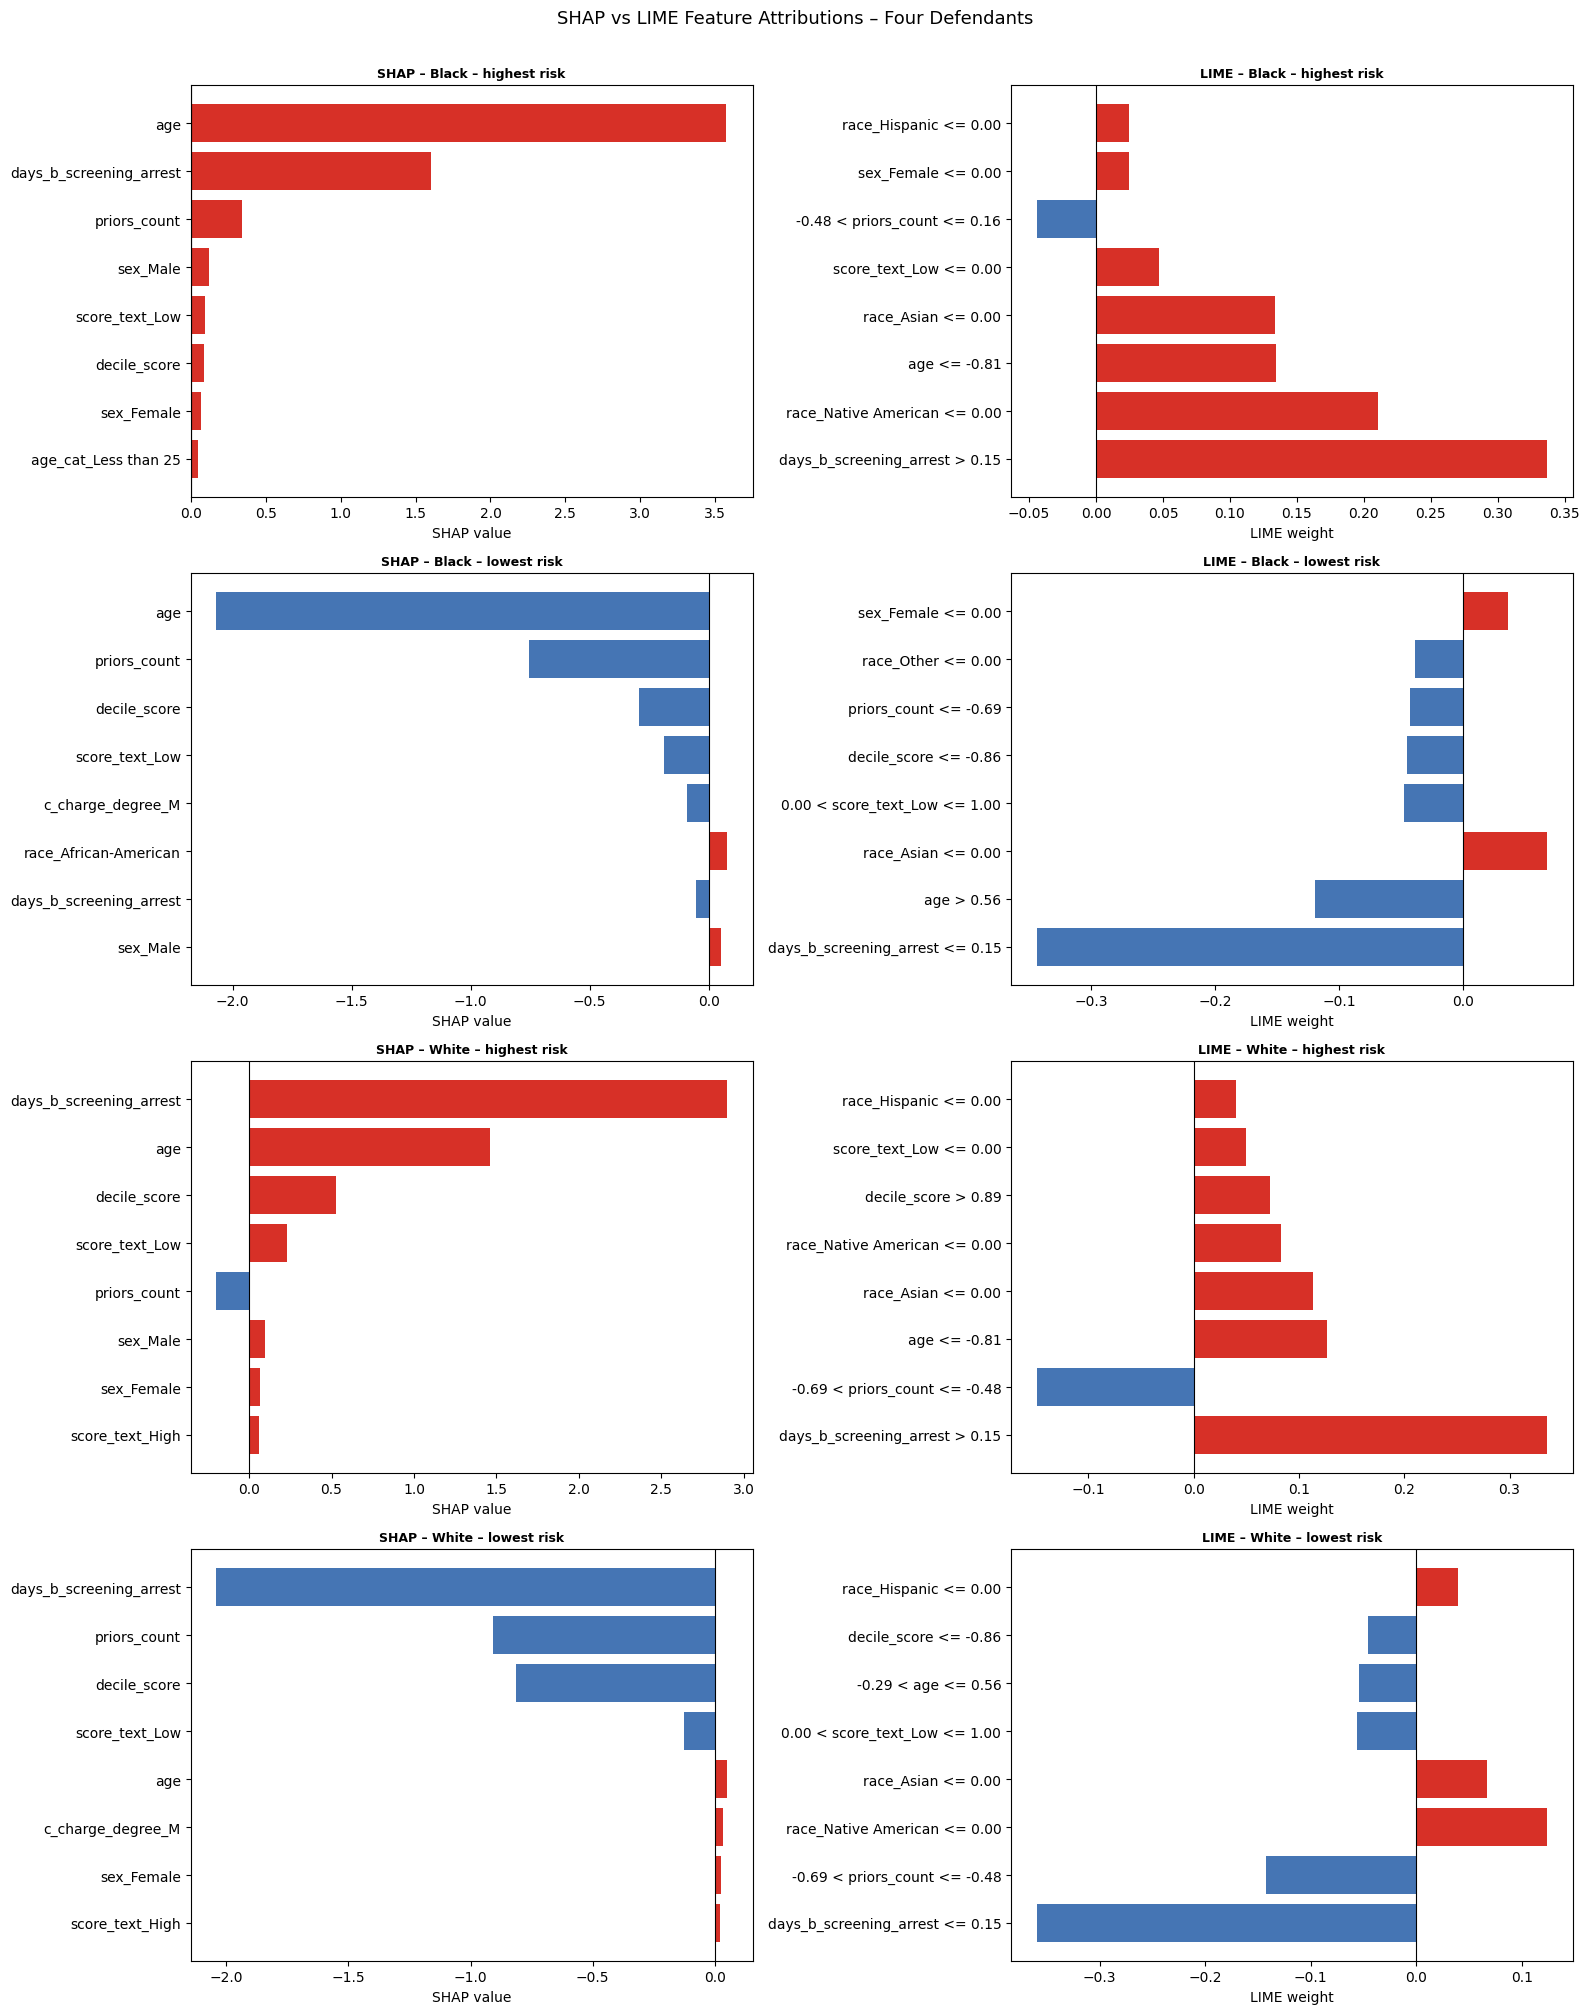

Saved: shap_vs_lime.png


In [ ]:
# Side-by-side SHAP vs LIME comparison
fig_compare, axes = plt.subplots(4, 2, figsize=(16, 20))

for row_idx, (label, idx) in enumerate(individuals.items()):
    loc = X_test.index.get_loc(idx)

    # SHAP bar (left)
    ax_shap = axes[row_idx, 0]
    sv = shap_values[loc].values
    top8_idx = np.argsort(np.abs(sv))[-8:]
    colors   = ['#d73027' if sv[i] > 0 else '#4575b4' for i in top8_idx]
    ax_shap.barh(
        [all_feature_names[i][:35] for i in top8_idx],
        [sv[i] for i in top8_idx],
        color=colors,
    )
    ax_shap.axvline(0, color='black', linewidth=0.8)
    ax_shap.set_title(f'SHAP – {label}', fontsize=9, fontweight='bold')
    ax_shap.set_xlabel('SHAP value')

    # LIME bar (right)
    ax_lime = axes[row_idx, 1]
    lime_feat, lime_wt = zip(*lime_results[label][:8])
    lime_colors = ['#d73027' if w > 0 else '#4575b4' for w in lime_wt]
    ax_lime.barh(
        [f[:35] for f in lime_feat],
        lime_wt,
        color=lime_colors,
    )
    ax_lime.axvline(0, color='black', linewidth=0.8)
    ax_lime.set_title(f'LIME – {label}', fontsize=9, fontweight='bold')
    ax_lime.set_xlabel('LIME weight')

plt.suptitle('SHAP vs LIME Feature Attributions – Four Defendants', fontsize=13, y=1.005)
plt.tight_layout()
plt.savefig('shap_vs_lime.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: shap_vs_lime.png')

In [ ]:
# LIME vs SHAP Divergence Analysis
print('\n── LIME vs SHAP Divergence Analysis ──')
for label, idx in individuals.items():
    loc = X_test.index.get_loc(idx)
    shap_top = set(
        all_feature_names[i]
        for i in np.argsort(np.abs(shap_values[loc].values))[-5:]
    )
    lime_top = set(feat for feat, _ in lime_results[label][:5])
    agreement  = shap_top & lime_top
    divergence = shap_top.symmetric_difference(lime_top)
    print(f'\n  {label}')
    print(f'    Agreement  : {agreement}')
    print(f'    Divergence : {divergence}')

# Governance note:
# Where SHAP and LIME agree -> high confidence the feature truly matters.
# Where they diverge -> LIME's local linear approximation and SHAP's
# exact marginal attribution answer slightly different questions.
# Divergence signals method-sensitivity, a red flag for high-stakes
# decisions: no single post-hoc method should be treated as ground truth.


── LIME vs SHAP Divergence Analysis ──

  Black – highest risk
    Agreement  : set()
    Divergence : {'sex_Male', 'age', 'score_text_Low <= 0.00', 'priors_count', 'race_Native American <= 0.00', 'days_b_screening_arrest > 0.15', 'race_Asian <= 0.00', 'score_text_Low', 'days_b_screening_arrest', 'age <= -0.81'}

  Black – lowest risk
    Agreement  : set()
    Divergence : {'c_charge_degree_M', 'age', 'age > 0.56', 'priors_count', 'race_Asian <= 0.00', 'decile_score <= -0.86', 'decile_score', '0.00 < score_text_Low <= 1.00', 'score_text_Low', 'days_b_screening_arrest <= 0.15'}

  White – highest risk
    Agreement  : set()
    Divergence : {'age', 'priors_count', 'race_Native American <= 0.00', 'days_b_screening_arrest > 0.15', 'race_Asian <= 0.00', 'decile_score', 'score_text_Low', 'days_b_screening_arrest', 'age <= -0.81', '-0.69 < priors_count <= -0.48'}

  White – lowest risk
    Agreement  : set()
    Divergence : {'age', 'priors_count', 'race_Native American <= 0.00', 'race_Asi

### 8.7 DiCE Counterfactuals


In [ ]:
print('Generating counterfactuals with DiCE …')

train_df = X_train.copy()
train_df[target] = y_train.values

dice_data = dice_ml.Data(
    dataframe=train_df,
    continuous_features=numeric_features,
    outcome_name=target,
)

dice_model = dice_ml.Model(
    model=gbt_pipeline,
    backend='sklearn',
    model_type='classifier',
)

exp_dice = Dice(dice_data, dice_model, method='genetic')

cf_records = []

for label, idx in individuals.items():
    query = X_test.loc[[idx]]
    original_pred = gbt_pipeline.predict(query)[0]
    desired_class = "opposite"  # flip the prediction

    try:
        cf = exp_dice.generate_counterfactuals(
            query_instances=query,
            total_CFs=3,
            desired_class=desired_class,
            permitted_range={
                'age':          [18, 70],
                'priors_count': [0, 38],
            },
            features_to_vary=['age', 'priors_count', 'c_charge_degree'],
        )
        cf_df = cf.cf_examples_list[0].final_cfs_df
        print(f'\n  DiCE – {label}  (original pred={original_pred})')
        print(cf_df.to_string(index=False))

        # Flag immutable feature changes
        for _, cf_row in cf_df.iterrows():
            immutable_changes = []
            for feat in ['race', 'sex']:
                if feat in cf_row.index and cf_row[feat] != query.iloc[0][feat]:
                    immutable_changes.append(feat)
            changed = [
                f for f in numeric_features + category_features
                if f in cf_row.index and str(cf_row[f]) != str(query.iloc[0][f])
            ]
            cf_records.append(
                {
                    'defendant': label,
                    'original_pred': original_pred,
                    'changed_features': ', '.join(changed),
                    'immutable_changes': ', '.join(immutable_changes) if immutable_changes else 'None',
                }
            )
    except Exception as e:
        print(f'  DiCE failed for {label}: {e}')

cf_summary = pd.DataFrame(cf_records)
print('\nCounterfactual summary:')
print(cf_summary.to_string(index=False))

Generating counterfactuals with DiCE …


100%|██████████| 1/1 [00:14<00:00, 14.95s/it]



  DiCE – Black – highest risk  (original pred=1)
 age  priors_count  days_b_screening_arrest  decile_score      age_cat  sex             race c_charge_degree score_text  two_year_recid
  69             4                      7.0             5 Less than 25 Male African-American               M     Medium               0
  69             5                      7.0             5 Less than 25 Male African-American               F     Medium               0
  68             1                      7.0             5 Less than 25 Male African-American               F     Medium               0


100%|██████████| 1/1 [00:00<00:00,  2.85it/s]



  DiCE – Black – lowest risk  (original pred=0)
 age  priors_count  days_b_screening_arrest  decile_score         age_cat  sex             race c_charge_degree score_text  two_year_recid
  18             0                     -1.0             1 Greater than 45 Male African-American               M        Low               1
  18             0                     -1.0             1 Greater than 45 Male African-American               F        Low               1
  18             3                     -1.0             1 Greater than 45 Male African-American               M        Low               1


100%|██████████| 1/1 [00:03<00:00,  3.40s/it]



  DiCE – White – highest risk  (original pred=1)
 age  priors_count  days_b_screening_arrest  decile_score      age_cat  sex      race c_charge_degree score_text  two_year_recid
  58             1                     28.0             9 Less than 25 Male Caucasian               M       High               0
  62             1                     28.0             9 Less than 25 Male Caucasian               M       High               0
  69             1                     28.0             9 Less than 25 Male Caucasian               M       High               0


100%|██████████| 1/1 [00:00<00:00,  3.16it/s]


  DiCE – White – lowest risk  (original pred=0)
 age  priors_count  days_b_screening_arrest  decile_score age_cat  sex      race c_charge_degree score_text  two_year_recid
  39             4                    -29.0             1 25 - 45 Male Caucasian               F        Low               1
  40             8                    -29.0             1 25 - 45 Male Caucasian               F        Low               1
  41             8                    -29.0             1 25 - 45 Male Caucasian               F        Low               1

Counterfactual summary:
           defendant  original_pred     changed_features immutable_changes
Black – highest risk              1 age, c_charge_degree              None
Black – highest risk              1    age, priors_count              None
Black – highest risk              1    age, priors_count              None
 Black – lowest risk              0                  age              None
 Black – lowest risk              0 age, c_charge_degre

### 8.8 Governance Memo


This analysis evaluates the transparency and fairness risks of a Gradient Boosted Tree model trained to predict two-year recidivism using the COMPAS dataset. Three complementary explainability methods, SHAP, LIME, and DiCE counterfactual explanations, were applied to understand how predictions are generated and whether they raise governance concerns.

SHAP global explanations indicate that age, priors_count, days_b_screening_arrest, and decile_score are among the strongest contributors to predicted risk across individuals. Waterfall plots for selected high- and low-risk defendants show that these features consistently influence classification outcomes. However, subgroup performance analysis suggests a difference in error rates across racial groups: the false positive rate for Black defendants is higher than for White defendants. This pattern indicates some imbalance in misclassification risk, even though overall model accuracy remains similar across groups.

LIME attributions provide locally interpretable explanations for the same individuals but show limited overlap with SHAP’s highest-ranked features. This difference reflects the methodological distinction between SHAP’s marginal contribution approach and LIME’s local linear approximation. Where the two methods differ, the results should be interpreted with caution, as LIME explanations can vary depending on neighbourhood sampling and kernel settings. The comparison highlights that no single post-hoc explanation method should be treated as fully definitive on its own.

DiCE counterfactual explanations show that prediction changes can be achieved by modifying age, priors_count, or charge degree. No generated counterfactual required changes to race or sex, suggesting that recourse is available through mutable features within the model framework.


LIMITATIONS:

Post-hoc explainability methods approximate model behaviour rather than directly revealing internal decision processes. SHAP assumes partial feature independence, which may not fully hold for correlated criminal-history variables. LIME explanations are sensitive to sampling choices, and counterfactual feasibility does not necessarily imply real-world practicality.


RECOMMENDATIONS
1. Re-run subgroup FPR/FNR diagnostics alongside explainability outputs during periodic evaluation.
2.	Monitor differences in error rates across groups before deployment updates or policy use.
3.	Provide defendants with counterfactual-style recourse statements limited to mutable features where appropriate.
4.	Use multiple explanation methods together when interpreting model behaviour in high-stakes settings.



# 9. Individual Assignment 3 - COMPAS Fairness Audit

**Acknowledgement of AI used:**  
I used an AI tool (ChatGPT) to assist with structuring the disparity audit workflow and translating lecture concepts into code. All codes and interpretations were reviewed, understood, and finalised by me.

### Tasks
1. Compute AIR, ME, and SMD using `solas-ai` for race and sex  
2. Intersectional analysis (race × sex)
3. FPR and FNR disparities with two-proportion z-test significance  
4. Publication-quality grouped bar chart of error rates by race  
5. Compliance memo

In [ ]:
!pip install solas-ai

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest
import solas_disparity as sd

In [ ]:
df["high_risk"] = (df["score_text"] != "Low").astype(int)

## 9.1 AIR, ME, and SMD using `solas-ai` (Race & Sex)

### 9.1.1 AIR by Race

In [ ]:
reference_group = "Caucasian"

reference_rate = df[df["race"] == reference_group]["high_risk"].mean()

race_groups = [
    "African-American",
    "Hispanic",
    "Asian",
    "Other",
    "Native American"
]

results = []

for group in race_groups:
    group_rate = df[df["race"] == group]["high_risk"].mean()
    air = group_rate / reference_rate

    results.append({
        "group": group,
        "selection_rate": group_rate,
        "AIR": air
    })

air_race = pd.DataFrame(results)

print("=== AIR by Race (reference = Caucasian)")
print(air_race)

=== AIR by Race (reference = Caucasian)
              group  selection_rate       AIR
0  African-American        0.576063  1.740604
1          Hispanic        0.277014  0.837011
2             Asian        0.225806  0.682286
3             Other        0.204082  0.616643
4   Native American        0.727273  2.197492


### 9.1.2 AIR for Sex

In [ ]:
reference_group = "Male"

reference_rate = df[df["sex"] == reference_group]["high_risk"].mean()

sex_groups = ["Female"]

results = []

for group in sex_groups:
    group_rate = df[df["sex"] == group]["high_risk"].mean()
    air = group_rate / reference_rate

    results.append({
        "group": group,
        "selection_rate": group_rate,
        "AIR": air
    })

air_sex = pd.DataFrame(results)

print("=== AIR by Sex (reference = Male) ===")
print(air_sex)

=== AIR by Sex (reference = Male) ===
    group  selection_rate       AIR
0  Female        0.405106  0.889809


### 9.1.3 Marginal Effect by Race

In [ ]:
import statsmodels.formula.api as smf

me_model = smf.logit(
    "high_risk ~ C(race, Treatment('Caucasian'))",
    data=df
).fit()

print(me_model.summary())

Optimization terminated successfully.
         Current function value: 0.647422
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:              high_risk   No. Observations:                 6172
Model:                          Logit   Df Residuals:                     6166
Method:                           MLE   Df Model:                            5
Date:                Sun, 05 Apr 2026   Pseudo R-squ.:                 0.05794
Time:                        23:57:28   Log-Likelihood:                -3995.9
converged:                       True   LL-Null:                       -4241.7
Covariance Type:            nonrobust   LLR p-value:                5.310e-104
                                                          coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------------
Intercept                 

### 9.1.4 Marginal Effect for Sex

In [ ]:
import statsmodels.formula.api as smf

me_sex_model = smf.logit(
    "high_risk ~ C(sex, Treatment('Male'))",
    data=df
).fit()

print(me_sex_model.summary())

Optimization terminated successfully.
         Current function value: 0.686454
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:              high_risk   No. Observations:                 6172
Model:                          Logit   Df Residuals:                     6170
Method:                           MLE   Df Model:                            1
Date:                Mon, 06 Apr 2026   Pseudo R-squ.:                0.001149
Time:                        00:05:28   Log-Likelihood:                -4236.8
converged:                       True   LL-Null:                       -4241.7
Covariance Type:            nonrobust   LLR p-value:                  0.001799
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
Intercept                              -0.1794      0.028 

### 9.1.5 SMD by Race

In [ ]:
results = []

reference = df[df["race"] == "Caucasian"]["decile_score"]

race_groups = [
    "African-American",
    "Hispanic",
    "Asian",
    "Other",
    "Native American"
]

for group in race_groups:

    group_scores = df[df["race"] == group]["decile_score"]

    smd = (group_scores.mean() - reference.mean()) / (
        ((group_scores.std()**2 + reference.std()**2) / 2) ** 0.5
    )

    results.append({
        "group": group,
        "SMD": smd
    })

smd_race = pd.DataFrame(results)

print(smd_race)

              group       SMD
0  African-American  0.608287
1          Hispanic -0.098743
2             Asian -0.309588
3             Other -0.303697
4   Native American  1.008153


### 9.1.6 SMD for Sex

In [ ]:
female_scores = df[df["sex"] == "Female"]["decile_score"]
male_scores = df[df["sex"] == "Male"]["decile_score"]

smd_sex = (female_scores.mean() - male_scores.mean()) / (
    ((female_scores.std()**2 + male_scores.std()**2) / 2) ** 0.5
)

print("SMD (sex):", smd_sex)

SMD (sex): -0.15837358758137762


## 9.2 Intersectional Analysis (Race × Sex)

In [ ]:
df["race_sex"] = df["race"] + " × " + df["sex"]

reference_rate = df[df["race_sex"] == "Caucasian × Male"]["high_risk"].mean()

intersection_results = []

for group in df["race_sex"].unique():

    group_rate = df[df["race_sex"] == group]["high_risk"].mean()

    air = group_rate / reference_rate

    intersection_results.append({
        "group": group,
        "AIR": air
    })

intersection_air = pd.DataFrame(intersection_results)

intersection_air.sort_values("AIR")

,group,AIR
11,Asian × Female,0.000000
7,Hispanic × Female,0.270270
6,Other × Female,0.600451
0,Other × Male,0.655421
8,Asian × Male,0.764211
4,Hispanic × Male,0.993551
2,Caucasian × Male,1.000000
3,Caucasian × Female,1.208603
5,African-American × Female,1.568591
1,African-American × Male,1.877184


The intersectional analysis shows that Asian females have the lowest AIR (0.00) relative to the reference group Caucasian males, indicating the largest disparity. Because this value is below the EEOC 80% rule threshold (AIR < 0.80), it suggests potential disparate impact for this subgroup. The selection rate is zero, meaning no individuals in this group were classified as high risk.

## 9.3 FPR & FNR Disparities with Two-Proportion Z-Test

In [ ]:
df["pred"] = df["high_risk"]
df["actual"] = df["two_year_recid"]

def error_rates(group):

    tp = ((group.pred==1)&(group.actual==1)).sum()
    tn = ((group.pred==0)&(group.actual==0)).sum()
    fp = ((group.pred==1)&(group.actual==0)).sum()
    fn = ((group.pred==0)&(group.actual==1)).sum()

    return pd.Series({
        "FPR": fp/(fp+tn),
        "FNR": fn/(fn+tp),
        "FP": fp,
        "TN": tn,
        "FN": fn,
        "TP": tp
    })

race_errors = df.groupby("race").apply(error_rates)

race_errors

,FPR,FNR,FP,TN,FN,TP
race,,,,,,
African-American,0.423382,0.284768,641.0,873.0,473.0,1188.0
Asian,0.086957,0.375000,2.0,21.0,3.0,5.0
Caucasian,0.220141,0.496350,282.0,999.0,408.0,414.0
Hispanic,0.193750,0.582011,62.0,258.0,110.0,79.0
Native American,0.500000,0.000000,3.0,3.0,0.0,5.0
Other,0.127854,0.661290,28.0,191.0,82.0,42.0


In [ ]:
from statsmodels.stats.proportion import proportions_ztest

fp = [
    race_errors.loc["African-American","FP"],
    race_errors.loc["Caucasian","FP"]
]

n = [
    race_errors.loc["African-American","FP"] +
    race_errors.loc["African-American","TN"],

    race_errors.loc["Caucasian","FP"] +
    race_errors.loc["Caucasian","TN"]
]

z_stat, p_value = proportions_ztest(fp, n)

print("FPR p-value:", p_value)

FPR p-value: 5.03680700784675e-30


## 9.4 Publication-Quality Grouped Bar Chart of Error Rates by Race

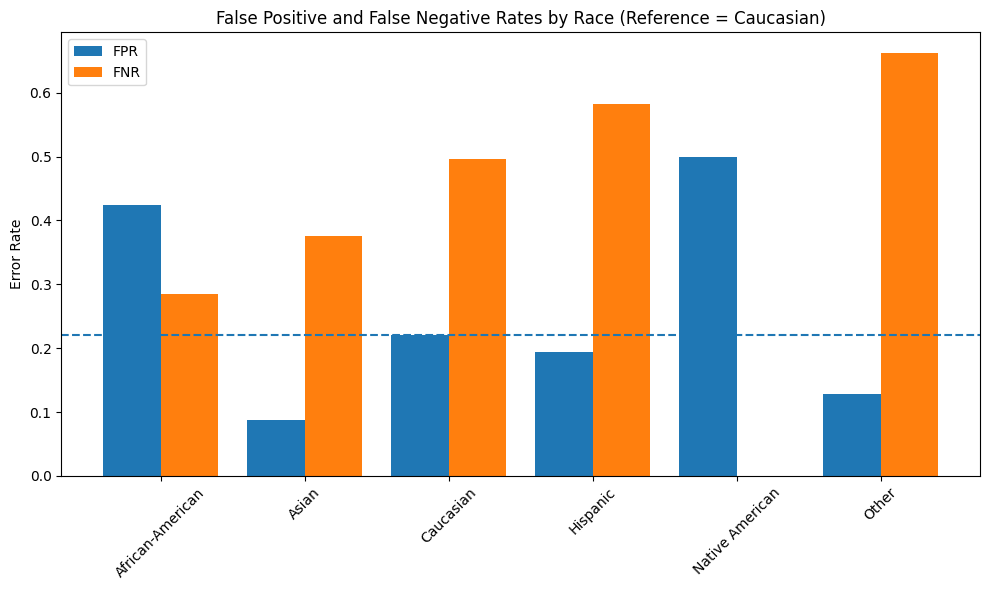

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plot_df = race_errors.reset_index()

x = np.arange(len(plot_df))

plt.figure(figsize=(10,6))

plt.bar(x-0.2, plot_df["FPR"], width=0.4, label="FPR")
plt.bar(x+0.2, plot_df["FNR"], width=0.4, label="FNR")

plt.xticks(x, plot_df["race"], rotation=45)

plt.axhline(
    plot_df[plot_df.race=="Caucasian"]["FPR"].values[0],
    linestyle="dashed"
)

plt.title("False Positive and False Negative Rates by Race (Reference = Caucasian)")
plt.ylabel("Error Rate")
plt.legend()

plt.tight_layout()
plt.show()

## 9.5 Compliance Memo

This analysis evaluates potential disparate impact in the COMPAS risk prediction model using fairness metrics consistent with EEOC guidance and the burden-shifting framework. Adverse Impact Ratio (AIR), Marginal Effect (ME), Standardized Mean Difference (SMD), and group error-rate disparities, including False Positive Rate (FPR) and False Negative Rate (FNR), were computed across race and sex to assess fairness in classification outcomes.

AIR results indicate that several demographic subgroups fall below the EEOC 80% rule threshold relative to the Caucasian reference group, suggesting potential disparate impact. Marginal Effect tests evaluate whether observed selection-rate differences are statistically significant, while Standardized Mean Difference measures effect-size differences in predicted risk scores across protected groups. Together, these metrics provide evidence supporting a prima facie disparity assessment under Step 1 of the burden-shifting framework.

Intersectional analysis combining race and sex identified Asian females as the subgroup with the lowest AIR relative to Caucasian males. This finding indicates that disparities may increase when protected characteristics interact rather than being evaluated independently. The selection rate for this subgroup was zero, which substantially reduced the AIR value and highlights the importance of examining intersectional effects in fairness audits.

Error-rate analysis further shows differences in false positive and false negative rates across racial groups. Two-proportion z-tests were conducted to evaluate whether these disparities are statistically significant. Differences in FPR and FNR reflect known trade-offs between calibration and equalized error rates when base rates differ across demographic groups.

Limitations of this analysis include small subgroup sample sizes, threshold sensitivity, and reliance on observational data rather than causal evidence. Results indicate measurable disparities that warrant further evaluation under Step 2 of the burden-shifting framework, including assessment of business necessity and consideration of less discriminatory alternatives.